# EDA: химические дескрипторы и биологическая активность (IC50, CC50, SI)

Это отдельный этап исследования перед построением моделей.  
Задача EDA — понять структуру данных, качество признаков и риски (пропуски, выбросы, мультиколлинеарность), чтобы затем осознанно выбрать подход к предобработке и моделированию.

**Важно для постановки задачи:**
- `SI` вычисляется на основе `IC50` и `CC50`, поэтому в задачах прогнозирования `SI` нельзя использовать `IC50`/`CC50` как признаки;
- в задачах прогнозирования `IC50`/`CC50` нельзя использовать `SI` (иначе будет утечка целевой переменной).


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (10, 6)

DATA_PATH = Path('data') / 'Данные_для_курсовой_Классическое_МО.xlsx'
df_raw = pd.read_excel(DATA_PATH)

print(f'Исходный shape: {df_raw.shape}')
print(f'Первые 8 колонок: {df_raw.columns[:8].tolist()}')


Исходный shape: (1001, 214)
Первые 8 колонок: ['Unnamed: 0', 'IC50, mM', 'CC50, mM', 'SI', 'MaxAbsEStateIndex', 'MaxEStateIndex', 'MinAbsEStateIndex', 'MinEStateIndex']


## 1) Обзор структуры данных: размерность, типы, базовые проверки

In [2]:
display(df_raw.head(3))

print('\nТипы данных:')
print(df_raw.dtypes.value_counts())

print('\nОбщее число колонок:', len(df_raw.columns))
print('Есть ли служебная колонка Unnamed: 0?', 'Unnamed: 0' in df_raw.columns)


,Unnamed: 0,"IC50, mM","CC50, mM",SI,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,0,6.239374,175.482382,28.125,5.094096,5.094096,0.387225,0.387225,0.417362,42.928571,...,0,0,0,0,0,0,0,0,3,0
1,1,0.771831,5.402819,7.000,3.961417,3.961417,0.533868,0.533868,0.462473,45.214286,...,0,0,0,0,0,0,0,0,3,0
2,2,223.808778,161.142320,0.720,2.627117,2.627117,0.543231,0.543231,0.260923,42.187500,...,0,0,0,0,0,0,0,0,3,0



Типы данных:
int64      107
float64    107
Name: count, dtype: int64

Общее число колонок: 214
Есть ли служебная колонка Unnamed: 0? True


**Вывод по структуре:**
- датасет содержит **1001 наблюдение и 214 колонок**;
- все признаки числовые (`int64` и `float64`), что удобно для классических моделей;
- колонка `Unnamed: 0` выглядит как технический индекс из Excel и не несет химического смысла — далее исключаем её из анализа и моделирования.


## 2) Анализ пропусков

Всего пропусков: 36
Колонок с пропусками: 12


,missing_count
MinAbsPartialCharge,3
MaxPartialCharge,3
MinPartialCharge,3
MaxAbsPartialCharge,3
BCUT2D_MWHI,3
BCUT2D_MRLOW,3
BCUT2D_MRHI,3
BCUT2D_LOGPLOW,3
BCUT2D_LOGPHI,3
BCUT2D_CHGLO,3


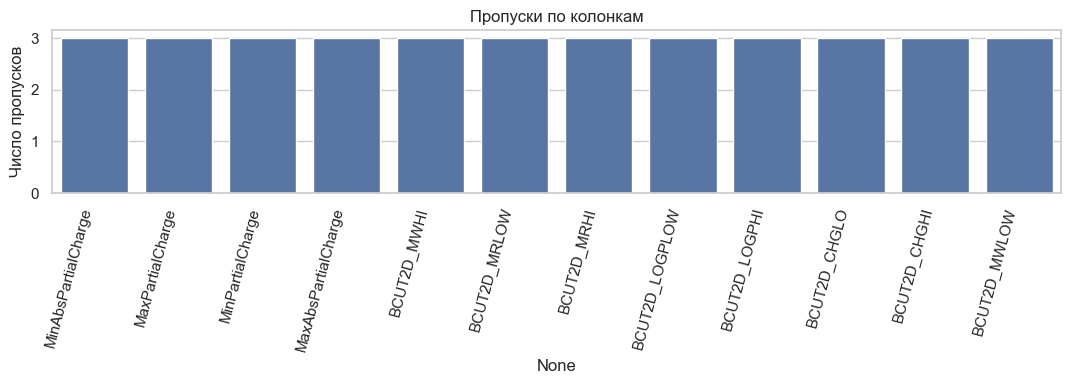

In [3]:
df = df_raw.copy()
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])

missing = df.isna().sum().sort_values(ascending=False)
missing = missing[missing > 0]

print('Всего пропусков:', int(df.isna().sum().sum()))
print('Колонок с пропусками:', missing.shape[0])

display(missing.to_frame('missing_count').head(15))

if not missing.empty:
    plt.figure(figsize=(11, 4))
    sns.barplot(x=missing.index, y=missing.values, color='#4C72B0')
    plt.xticks(rotation=75, ha='right')
    plt.ylabel('Число пропусков')
    plt.title('Пропуски по колонкам')
    plt.tight_layout()
    plt.show()


**Вывод по пропускам:**
- пропусков мало (единичные значения в ограниченном числе дескрипторов), массового провала качества данных нет;
- удалять строки целиком нерационально (каждая строка — отдельное соединение);
- для моделирования выбираем **медианную импутацию**, чтобы не искажать распределения и сохранить весь датасет.


## 3) Описательная статистика

In [4]:
targets = ['IC50, mM', 'CC50, mM', 'SI']

desc_targets = df[targets].describe().T
display(desc_targets)

selected_features = ['MolWt', 'TPSA', 'MolLogP', 'QED', 'qed', 'NumHDonors', 'NumHAcceptors']
selected_features = [c for c in selected_features if c in df.columns]

display(df[selected_features].describe().T)



,count,mean,std,min,25%,50%,75%,max
"IC50, mM",1001.0,222.805156,402.169734,0.003517,12.515396,46.585183,224.975928,4128.529377
"CC50, mM",1001.0,589.110728,642.867508,0.700808,99.999036,411.039342,894.089176,4538.976189
SI,1001.0,72.508823,684.482739,0.011489,1.433333,3.846154,16.566667,15620.600000


,count,mean,std,min,25%,50%,75%,max
MolWt,1001.0,348.262234,126.946370,110.156000,264.321000,315.457000,409.283000,904.777000
TPSA,1001.0,61.400769,45.743831,0.000000,29.460000,49.740000,83.760000,407.500000
MolLogP,1001.0,3.437327,2.142706,-5.750700,2.449200,3.423600,4.527800,12.822200
qed,1001.0,0.580412,0.212230,0.059567,0.442842,0.634981,0.742483,0.947265
NumHDonors,1001.0,1.181818,1.588996,0.000000,0.000000,1.000000,2.000000,15.000000
NumHAcceptors,1001.0,4.338661,3.206274,0.000000,2.000000,4.000000,5.000000,25.000000


**Вывод по статистике:**
- `IC50`, `CC50` и особенно `SI` имеют большой разброс между квартилями и максимумами;
- медианы существенно ниже средних значений, что указывает на правостороннюю асимметрию;
- это типично для биологических метрик: большинство соединений умеренные/слабые, а небольшая группа даёт экстремальные значения.


## 4) Распределения признаков (гистограммы)

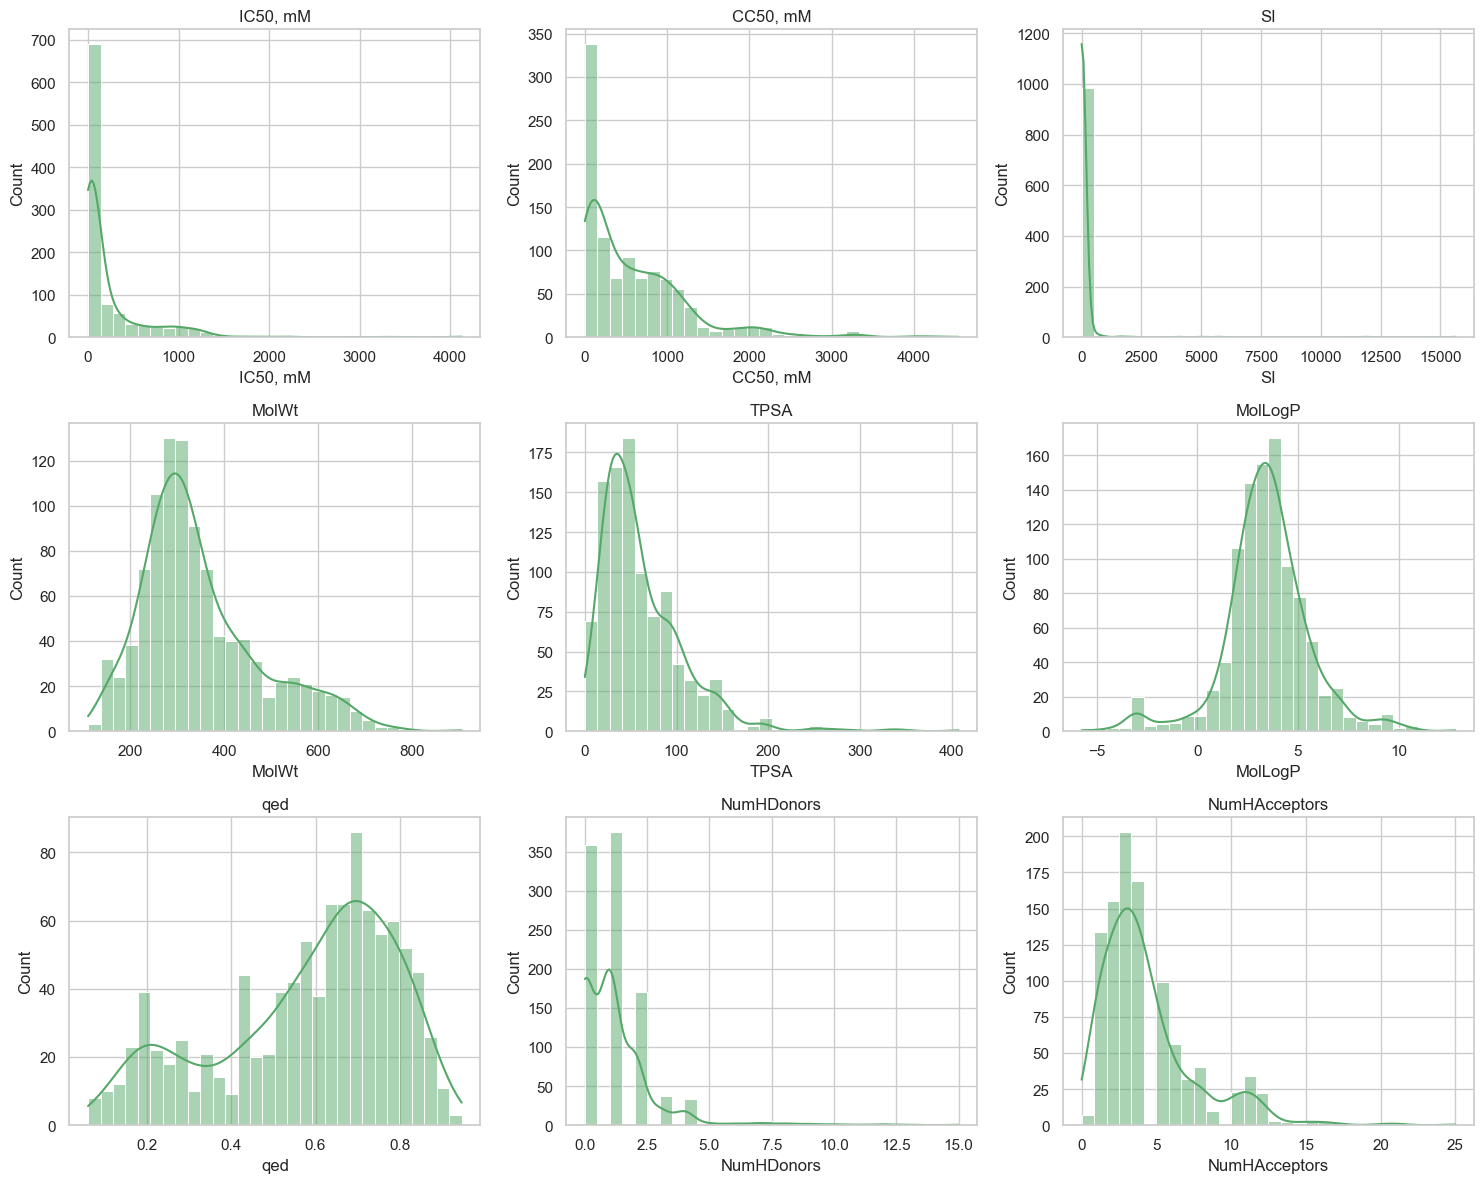

In [5]:
plot_cols = ['IC50, mM', 'CC50, mM', 'SI'] + selected_features
plot_cols = [c for c in plot_cols if c in df.columns]

ncols = 3
nrows = int(np.ceil(len(plot_cols) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4 * nrows))
axes = np.array(axes).reshape(-1)

for i, col in enumerate(plot_cols):
    sns.histplot(df[col], kde=True, bins=30, ax=axes[i], color='#55A868')
    axes[i].set_title(col)

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()


**Интерпретация распределений:**
- у целевых переменных заметны длинные правые хвосты;
- часть молекулярных дескрипторов ближе к «компактным» распределениям, но многие также негауссовы;
- для линейных моделей это означает чувствительность к масштабу и хвостам, поэтому масштабирование и регуляризация обязательны;
- для ансамблевых деревьев несимметричные распределения менее критичны, что часто даёт им преимущество на таких данных.


## 5) Boxplot и диагностика выбросов

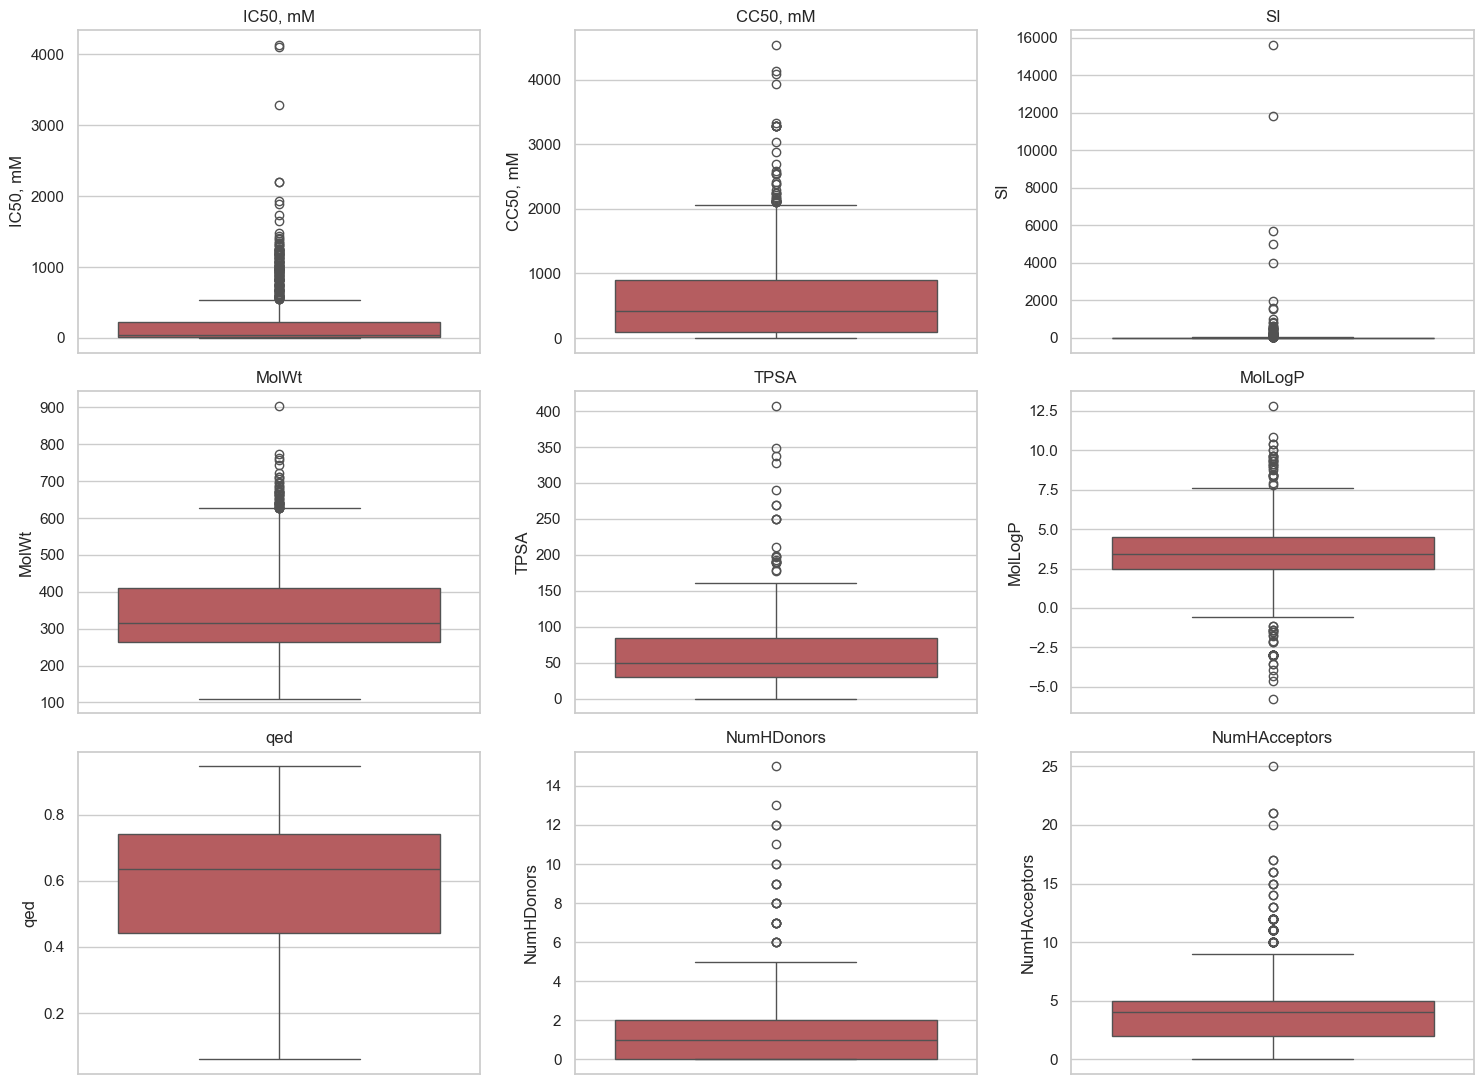

IC50, mM: доля IQR-выбросов = 0.147
CC50, mM: доля IQR-выбросов = 0.039
SI: доля IQR-выбросов = 0.125


In [6]:
box_cols = ['IC50, mM', 'CC50, mM', 'SI', 'MolWt', 'TPSA', 'MolLogP', 'QED', 'qed', 'NumHDonors', 'NumHAcceptors']
box_cols = [c for c in box_cols if c in df.columns]

fig, axes = plt.subplots(3, 3, figsize=(15, 11))
axes = axes.reshape(-1)

for i, col in enumerate(box_cols):
    sns.boxplot(y=df[col], ax=axes[i], color='#C44E52')
    axes[i].set_title(col)

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

# Оценим долю IQR-выбросов для таргетов
for t in ['IC50, mM', 'CC50, mM', 'SI']:
    q1 = df[t].quantile(0.25)
    q3 = df[t].quantile(0.75)
    iqr = q3 - q1
    low = q1 - 1.5 * iqr
    high = q3 + 1.5 * iqr
    outlier_share = ((df[t] < low) | (df[t] > high)).mean()
    print(f'{t}: доля IQR-выбросов = {outlier_share:.3f}')



**Вывод по выбросам:**
- выбросы действительно присутствуют, особенно по `SI`;
- в контексте drug discovery это может быть не «ошибка», а редкие, но ценные активные соединения;
- поэтому в базовой версии проекта **не удаляем выбросы жёстко**, чтобы не потерять потенциально информативные примеры;
- вместо этого используем устойчивые методы (деревья, бустинг) и аккуратную импутацию.


## 6) Корреляционный анализ (heatmap)

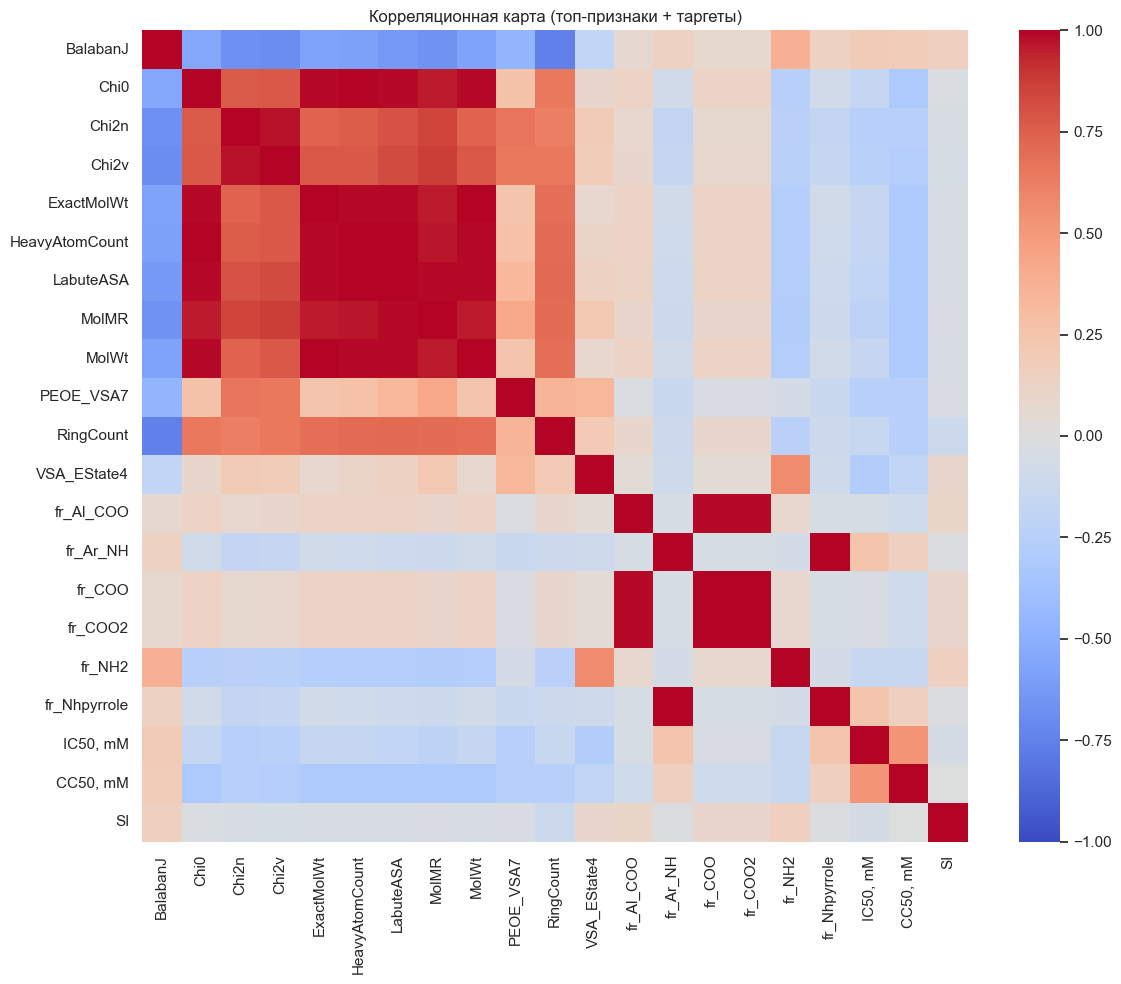

,"IC50, mM","CC50, mM",SI
BalabanJ,0.196842,0.189650,0.162955
fr_NH2,0.151699,0.150767,0.160470
RingCount,0.154305,0.253273,0.124444
fr_Al_COO,0.049499,0.101459,0.102414
fr_COO2,0.038873,0.096685,0.101115
fr_COO,0.038873,0.096685,0.101115
NumAromaticRings,0.011623,0.172691,0.088064
VSA_EState4,0.274203,0.190870,0.087837
FpDensityMorgan1,0.208710,0.293989,0.087341
VSA_EState6,0.060294,0.198992,0.082995


In [7]:
corr_targets = df.corr(numeric_only=True)[['IC50, mM', 'CC50, mM', 'SI']].drop(index=['IC50, mM', 'CC50, mM', 'SI'])

# Возьмем по 6 наиболее связанных признаков на каждый таргет
top_features = set()
for t in ['IC50, mM', 'CC50, mM', 'SI']:
    top_features.update(corr_targets[t].abs().sort_values(ascending=False).head(6).index.tolist())

top_features = sorted(top_features)
heatmap_df = df[top_features + ['IC50, mM', 'CC50, mM', 'SI']].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(heatmap_df, cmap='coolwarm', center=0, vmin=-1, vmax=1)
plt.title('Корреляционная карта (топ-признаки + таргеты)')
plt.tight_layout()
plt.show()

display(corr_targets.abs().sort_values(by='SI', ascending=False).head(10))


**Интерпретация корреляций:**
- сильных линейных связей у большинства дескрипторов с таргетами немного, что объясняет ограниченность чисто линейного подхода;
- заметна разная «природа» таргетов: набор полезных признаков для `SI` не совпадает полностью с `IC50`/`CC50`;
- это аргумент в пользу отдельных моделей под каждый таргет, а не одной универсальной модели.


## 7) Анализ целевых переменных (IC50, CC50, SI)

In [8]:
targets = ['IC50, mM', 'CC50, mM', 'SI']

target_stats = pd.DataFrame({
    'median': df[targets].median(),
    'mean': df[targets].mean(),
    'std': df[targets].std(),
    'skewness': df[targets].skew(),
    'p95': df[targets].quantile(0.95),
    'max': df[targets].max(),
})
display(target_stats)

# Классификационные пороги
thresholds = {
    'IC50_median': float(df['IC50, mM'].median()),
    'CC50_median': float(df['CC50, mM'].median()),
    'SI_median': float(df['SI'].median()),
    'SI_threshold_8': 8.0,
}
print(thresholds)

class_distribution = {
    'IC50 > median': (df['IC50, mM'] > thresholds['IC50_median']).mean(),
    'CC50 > median': (df['CC50, mM'] > thresholds['CC50_median']).mean(),
    'SI > median': (df['SI'] > thresholds['SI_median']).mean(),
    'SI > 8': (df['SI'] > 8).mean(),
}
print('\nДоля положительного класса:')
for k, v in class_distribution.items():
    print(f'{k}: {v:.3f}')


,median,mean,std,skewness,p95,max
"IC50, mM",46.585183,222.805156,402.169734,3.674929,1076.690512,4128.529377
"CC50, mM",411.039342,589.110728,642.867508,1.973333,1936.355856,4538.976189
SI,3.846154,72.508823,684.482739,18.013202,113.636364,15620.600000


{'IC50_median': 46.58518345980803, 'CC50_median': 411.0393423370522, 'SI_median': 3.846153846153846, 'SI_threshold_8': 8.0}

Доля положительного класса:
IC50 > median: 0.500
CC50 > median: 0.499
SI > median: 0.500
SI > 8: 0.357


**Вывод по целевым переменным:**
- все три таргета асимметричны, `SI` — наиболее «тяжелохвостый»;
- задачи по медиане почти сбалансированы (около 50/50), а `SI > 8` уже более сложная и умеренно несбалансированная постановка;
- для `SI` разумно ожидать более скромное качество в регрессии и более сильный разброс метрик между моделями.


## 8) Решения по предобработке перед моделями

In [9]:
preprocessing_plan = pd.DataFrame(
    {
        'Шаг': [
            'Удаление служебного признака',
            'Обработка пропусков',
            'Масштабирование',
            'Train/test split',
            'Fix random_state',
            'Anti-leakage правила',
        ],
        'Решение': [
            'Удалить `Unnamed: 0`',
            'SimpleImputer(strategy="median")',
            'StandardScaler (для линейных моделей)',
            'test_size=0.2',
            'random_state=42',
            'Descriptor-only: удалить IC50, CC50, SI и target-like производные',
        ],
    }
)

display(preprocessing_plan)



,Шаг,Решение
0,Удаление служебного признака,Удалить `Unnamed: 0`
1,Обработка пропусков,"SimpleImputer(strategy=""median"")"
2,Масштабирование,StandardScaler (для линейных моделей)
3,Train/test split,test_size=0.2
4,Fix random_state,random_state=42
5,Anti-leakage правила,"Descriptor-only: удалить IC50, CC50, SI и targ..."


## 9) Расширенный EDA для финального отчета

Блок ниже дополняет базовый EDA визуализациями, которые напрямую поддерживают финальные выводы отчета: распределения targets, выбросы, log-transform, корреляции, диагностические графики моделей, feature importance, confusion matrix, ROC и PR curves. Все модельные диагностические графики строятся в descriptor-only постановке: endpoint/target-like признаки исключаются из `X` до обучения.


In [10]:
from sklearn.ensemble import GradientBoostingClassifier, GradientBoostingRegressor, RandomForestClassifier, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, PrecisionRecallDisplay, RocCurveDisplay
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from ml_common import RANDOM_STATE, get_target_like_columns, validate_no_target_like_columns

TARGETS = ['IC50, mM', 'CC50, mM', 'SI']
KEY_DESCRIPTOR_CANDIDATES = ['MolWt', 'TPSA', 'MolLogP', 'QED', 'qed', 'NumHDonors', 'NumHAcceptors']
KEY_DESCRIPTORS = [col for col in KEY_DESCRIPTOR_CANDIDATES if col in df.columns]
TARGET_LIKE_IN_DATA = get_target_like_columns(df.columns)
DESCRIPTOR_COLUMNS = [col for col in df.columns if col not in set(TARGET_LIKE_IN_DATA)]

print('Target-like columns excluded from X:', TARGET_LIKE_IN_DATA)
print('Number of descriptor-only features:', len(DESCRIPTOR_COLUMNS))



Target-like columns excluded from X: ['IC50, mM', 'CC50, mM', 'SI']
Number of descriptor-only features: 210


### 9.1 Распределения target-переменных: histogram + KDE

Цель графиков — показать, насколько `IC50`, `CC50` и `SI` отличаются от нормального распределения. Это важно для выбора моделей: сильная асимметрия и тяжелые хвосты обычно ухудшают линейные модели и делают ансамбли деревьев более конкурентными.


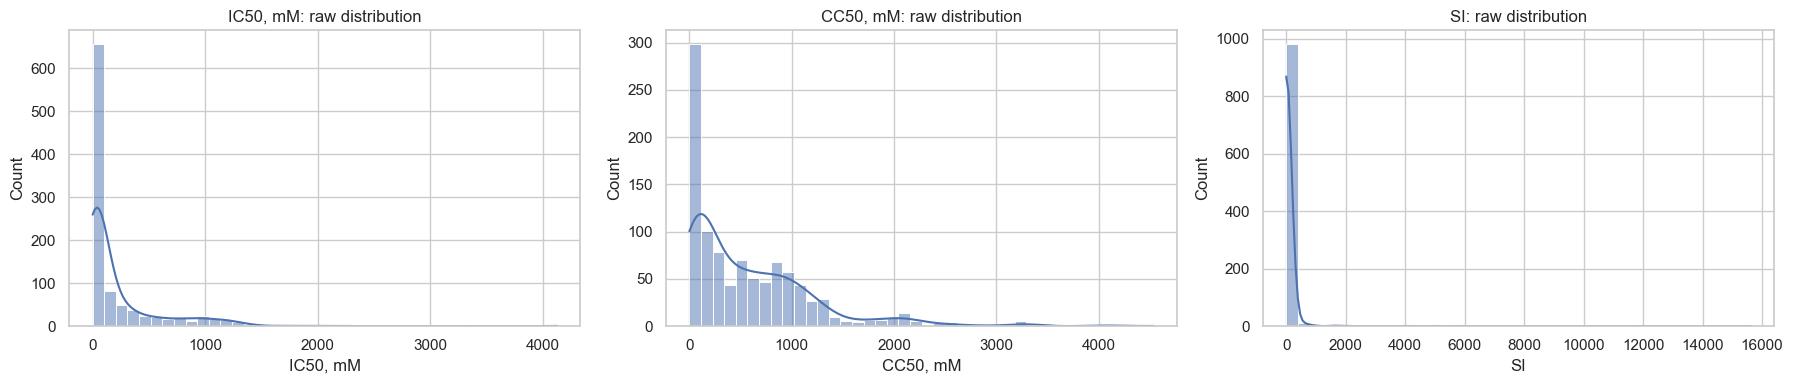

,mean,median,std,skewness,p95,max
"IC50, mM",222.805156,46.585183,402.169734,3.674929,1076.690512,4128.529377
"CC50, mM",589.110728,411.039342,642.867508,1.973333,1936.355856,4538.976189
SI,72.508823,3.846154,684.482739,18.013202,113.636364,15620.600000


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, target in zip(axes, TARGETS):
    sns.histplot(df[target].dropna(), kde=True, bins=40, ax=ax, color='#4C72B0')
    ax.set_title(f'{target}: raw distribution')
    ax.set_xlabel(target)
plt.tight_layout()
plt.show()

target_distribution_summary = pd.DataFrame({
    'mean': df[TARGETS].mean(),
    'median': df[TARGETS].median(),
    'std': df[TARGETS].std(),
    'skewness': df[TARGETS].skew(),
    'p95': df[TARGETS].quantile(0.95),
    'max': df[TARGETS].max(),
})
display(target_distribution_summary)



**Вывод.** Для всех targets ожидается правосторонняя асимметрия: среднее выше медианы, а максимум существенно превосходит верхние квартили. Самый тяжелый хвост у `SI`, потому что это отношение `CC50 / IC50`; небольшие значения `IC50` могут резко увеличивать `SI`. Поэтому в дальнейшем важно не удалять экстремумы механически и использовать модели, устойчивые к нелинейностям и хвостам.


### 9.2 Boxplot-анализ выбросов: targets и ключевые дескрипторы

Boxplot позволяет увидеть не только выбросы в endpoints, но и потенциально проблемные молекулярные дескрипторы (`MolWt`, `TPSA`, `MolLogP`, `QED/qed`, `NumHDonors`, `NumHAcceptors`).


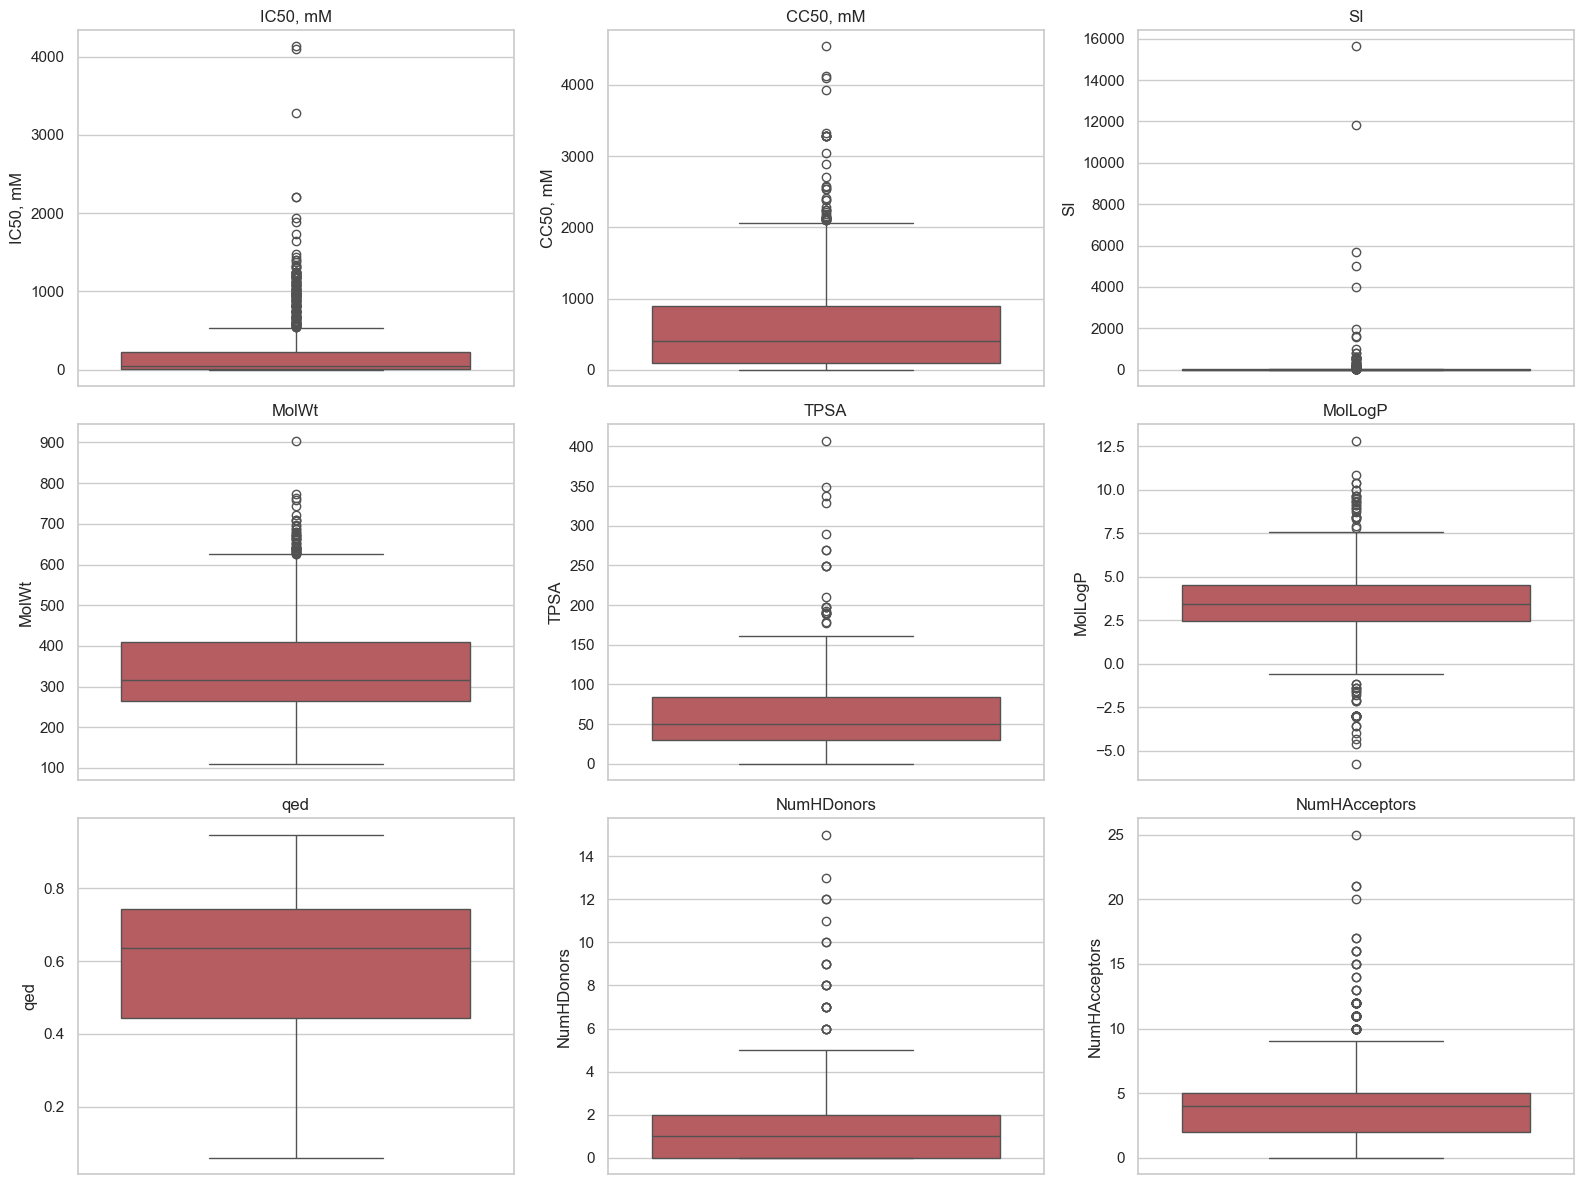

,outlier_share_iqr,median,p95,max
"IC50, mM",0.146853,46.585183,1076.690512,4128.529377
SI,0.124875,3.846154,113.636364,15620.600000
NumHAcceptors,0.095904,4.000000,11.000000,25.000000
MolLogP,0.064935,3.423600,6.847200,12.822200
MolWt,0.045954,315.457000,617.705000,904.777000
"CC50, mM",0.038961,411.039342,1936.355856,4538.976189
NumHDonors,0.022977,1.000000,4.000000,15.000000
TPSA,0.021978,49.740000,143.720000,407.500000
qed,0.000000,0.634981,0.850539,0.947265


In [12]:
boxplot_cols = TARGETS + KEY_DESCRIPTORS
ncols = 3
nrows = int(np.ceil(len(boxplot_cols) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4 * nrows))
axes = np.array(axes).reshape(-1)

for idx, col in enumerate(boxplot_cols):
    sns.boxplot(y=df[col], ax=axes[idx], color='#C44E52')
    axes[idx].set_title(col)
for idx in range(len(boxplot_cols), len(axes)):
    axes[idx].axis('off')
plt.tight_layout()
plt.show()

def iqr_outlier_share(series: pd.Series) -> float:
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    low = q1 - 1.5 * iqr
    high = q3 + 1.5 * iqr
    return float(((series < low) | (series > high)).mean())

outlier_table = pd.DataFrame({
    'outlier_share_iqr': {col: iqr_outlier_share(df[col].dropna()) for col in boxplot_cols},
    'median': {col: df[col].median() for col in boxplot_cols},
    'p95': {col: df[col].quantile(0.95) for col in boxplot_cols},
    'max': {col: df[col].max() for col in boxplot_cols},
}).sort_values('outlier_share_iqr', ascending=False)
display(outlier_table)



**Вывод.** Наиболее сильные выбросы ожидаются у `SI` и части размерных/полярных дескрипторов. Агрессивное удаление outliers не используется, потому что в drug discovery именно хвосты могут содержать наиболее интересные соединения: высокоселективные, высокоактивные или токсичные. Более корректная стратегия — robust preprocessing внутри cross-validation, анализ ошибок по хвостам и модели, устойчивые к нелинейным зависимостям.


### 9.3 До и после `log1p` transformation

Лог-преобразование не применяется как leakage-признак в `X`, но полезно для EDA и для понимания формы target-распределений. Сравнение raw vs `log1p` показывает, насколько тяжелые хвосты сжимаются.


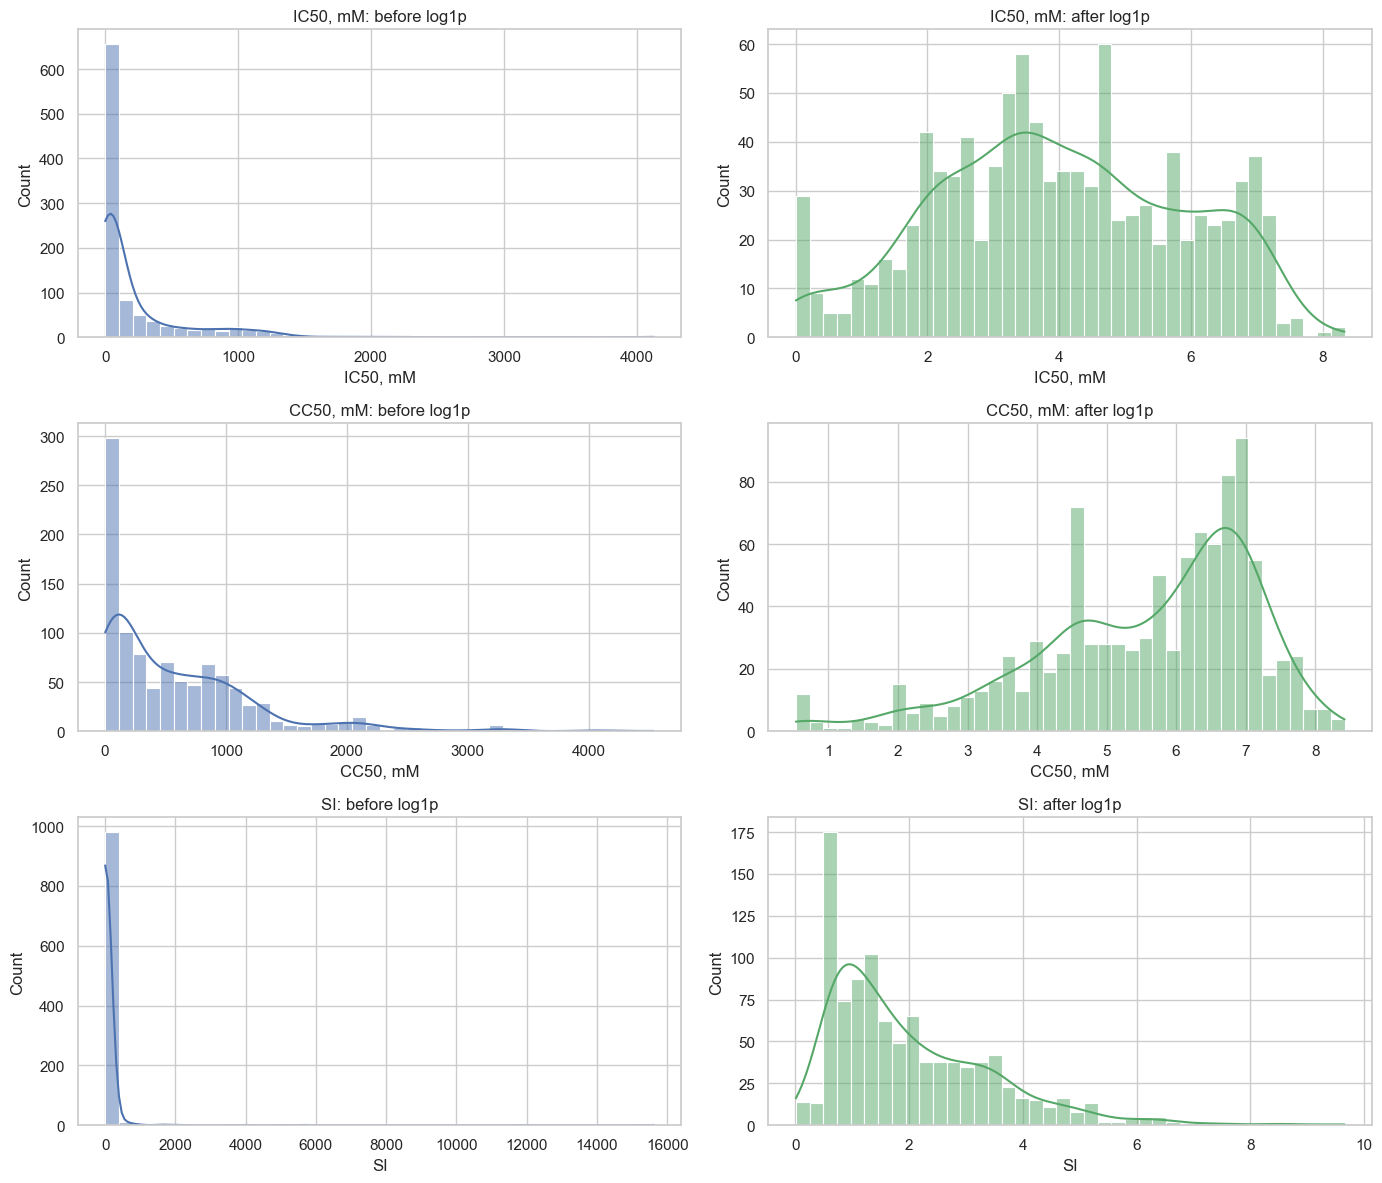

,raw_skewness,log1p_skewness
"IC50, mM",3.674929,-0.029113
"CC50, mM",1.973333,-0.907702
SI,18.013202,1.432640


In [13]:
fig, axes = plt.subplots(3, 2, figsize=(14, 12))
for row, target in enumerate(TARGETS):
    sns.histplot(df[target].dropna(), kde=True, bins=40, ax=axes[row, 0], color='#4C72B0')
    axes[row, 0].set_title(f'{target}: before log1p')
    sns.histplot(np.log1p(df[target].dropna()), kde=True, bins=40, ax=axes[row, 1], color='#55A868')
    axes[row, 1].set_title(f'{target}: after log1p')
plt.tight_layout()
plt.show()

log_transform_summary = pd.DataFrame({
    'raw_skewness': df[TARGETS].skew(),
    'log1p_skewness': np.log1p(df[TARGETS]).skew(),
})
display(log_transform_summary)



**Вывод.** `log1p` обычно уменьшает правостороннюю асимметрию и делает распределения ближе к симметричным. Это объясняет, почему для regression-задач полезно рассматривать target transformation. Важно: логарифмы targets нельзя использовать как признаки; они допустимы только как трансформация `y` внутри корректного pipeline или как EDA-визуализация.


### 9.4 Correlation heatmap: targets и ключевые признаки

Корреляционный анализ нужен для двух целей: найти признаки, потенциально связанные с targets, и явно увидеть leakage-опасные связи между `IC50`, `CC50` и `SI`.


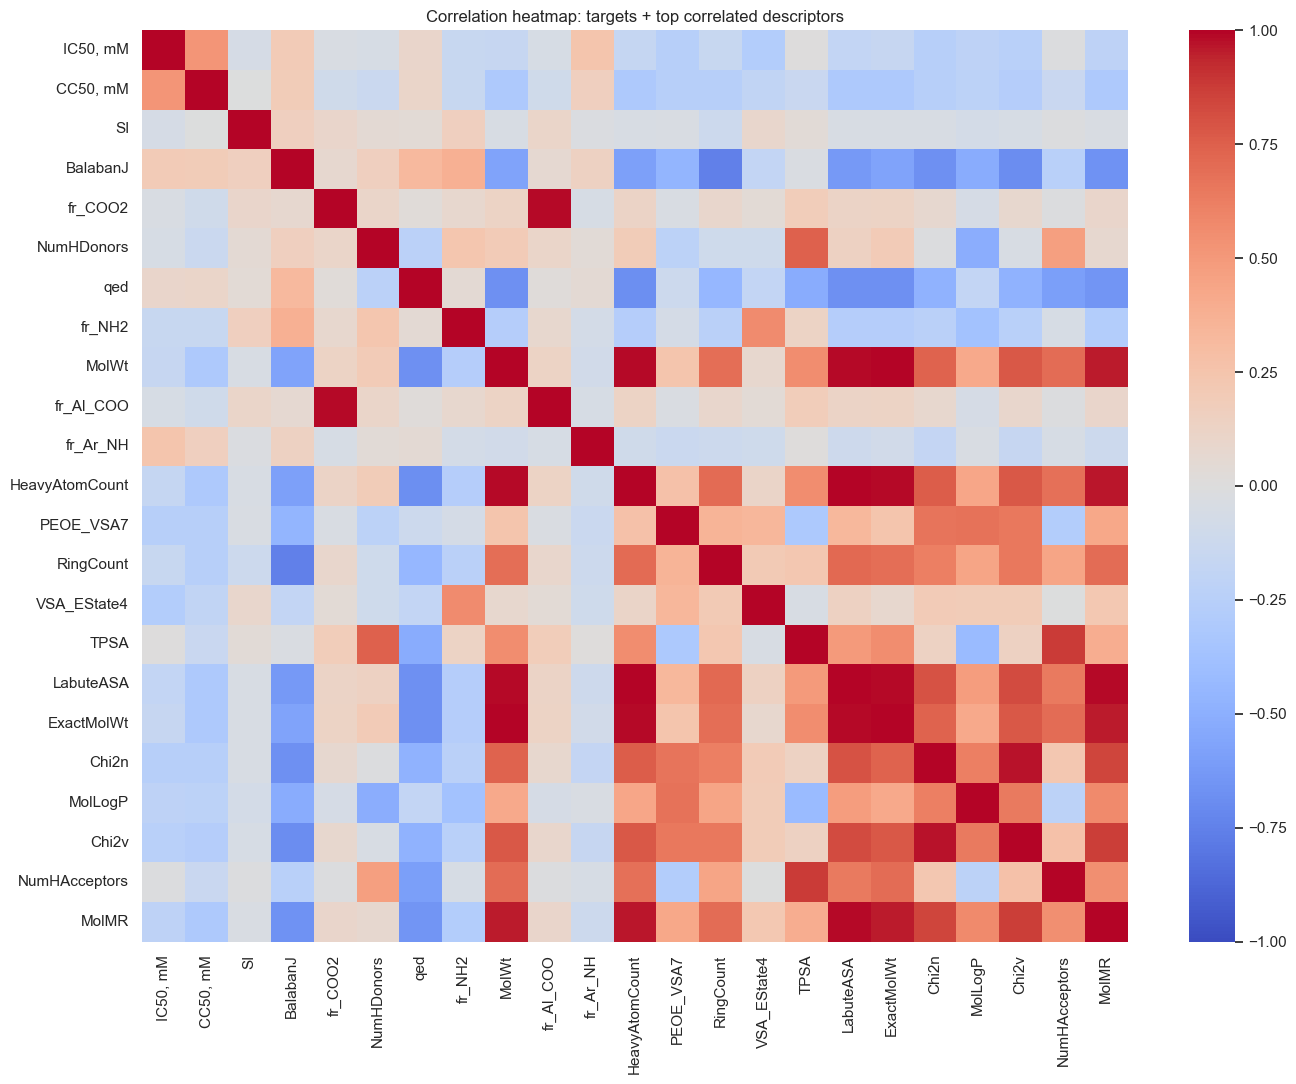


Top descriptors by absolute correlation with IC50, mM:


,abs_corr
VSA_EState4,0.274203
Chi2n,0.257058
PEOE_VSA7,0.255988
Chi2v,0.249164
fr_Ar_NH,0.245511
fr_Nhpyrrole,0.245511
Chi4v,0.243600
Chi4n,0.243497
Chi3n,0.239741
Chi3v,0.237759



Top descriptors by absolute correlation with CC50, mM:


,abs_corr
MolMR,0.310111
LabuteASA,0.309191
MolWt,0.306439
ExactMolWt,0.306382
HeavyAtomCount,0.305169
Chi0,0.304792
Chi1,0.304380
HeavyAtomMolWt,0.303163
Kappa1,0.302206
Chi1v,0.301525



Top descriptors by absolute correlation with SI:


,abs_corr
BalabanJ,0.162955
fr_NH2,0.160470
RingCount,0.124444
fr_Al_COO,0.102414
fr_COO2,0.101115
fr_COO,0.101115
NumAromaticRings,0.088064
VSA_EState4,0.087837
FpDensityMorgan1,0.087341
VSA_EState6,0.082995


In [14]:
correlation_base = TARGETS + KEY_DESCRIPTORS
correlation_base = [col for col in correlation_base if col in df.columns]

corr_to_targets = df.corr(numeric_only=True)[TARGETS].drop(index=TARGETS, errors='ignore')
top_corr_features = set(KEY_DESCRIPTORS)
for target in TARGETS:
    top_corr_features.update(corr_to_targets[target].abs().sort_values(ascending=False).head(5).index)

heatmap_cols = TARGETS + [col for col in top_corr_features if col in df.columns and col not in TARGETS]
heatmap_corr = df[heatmap_cols].corr()

plt.figure(figsize=(14, 11))
sns.heatmap(heatmap_corr, cmap='coolwarm', center=0, vmin=-1, vmax=1, annot=False)
plt.title('Correlation heatmap: targets + top correlated descriptors')
plt.tight_layout()
plt.show()

for target in TARGETS:
    print(f'\nTop descriptors by absolute correlation with {target}:')
    display(corr_to_targets[target].abs().sort_values(ascending=False).head(10).to_frame('abs_corr'))



**Вывод.** Если самые сильные связи обнаруживаются между target-переменными или их производными, это не полезный сигнал, а потенциальный leakage. Полезными считаются связи targets с молекулярными дескрипторами, доступными до эксперимента. Невысокие линейные корреляции также объясняют, почему Logistic Regression не доминирует и почему деревья/бустинг лучше извлекают нелинейный сигнал.


### 9.5 Fact vs Prediction для лучших regression-моделей

Диаграммы `y_true` vs `y_pred` показывают, где модель систематически ошибается: на малых значениях, на хвостах распределения или по всему диапазону. Линия `y=x` соответствует идеальному прогнозу.


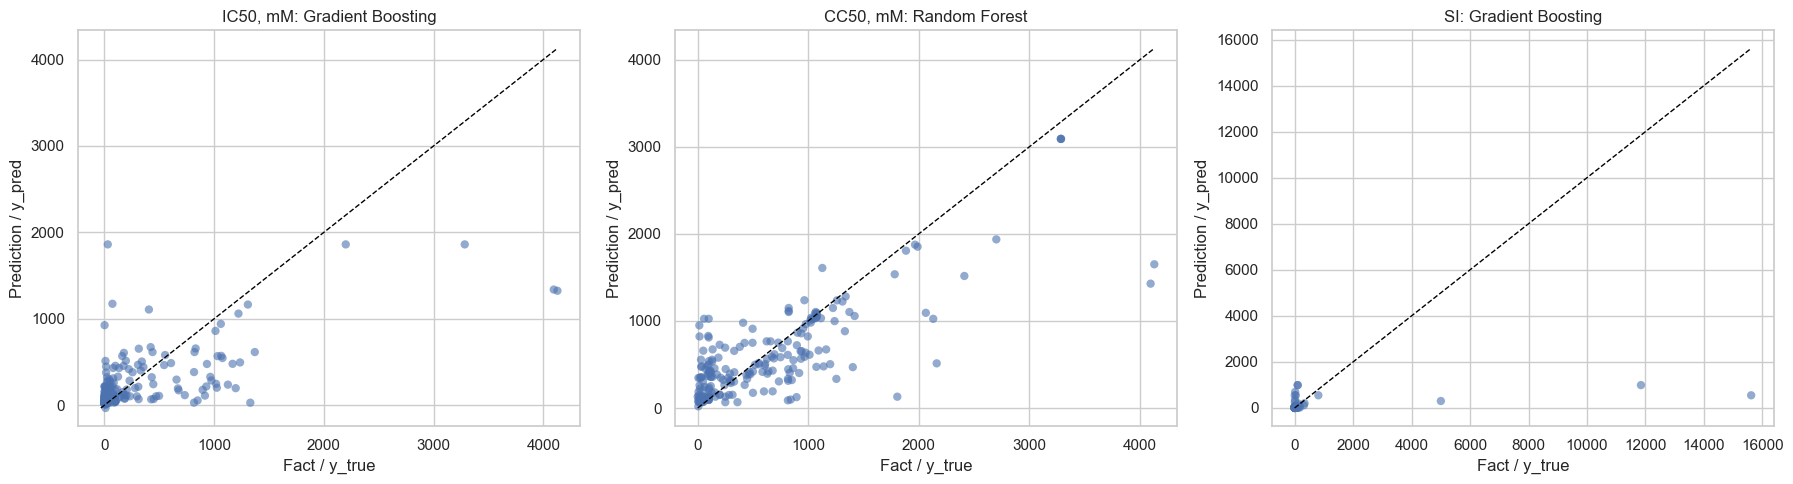

In [15]:
def descriptor_matrix(data: pd.DataFrame) -> pd.DataFrame:
    X = data[[col for col in data.columns if col not in set(get_target_like_columns(data.columns))]].copy()
    validate_no_target_like_columns(X)
    return X

REGRESSION_BEST_MODELS = {
    'IC50, mM': ('Gradient Boosting', GradientBoostingRegressor(random_state=RANDOM_STATE)),
    'CC50, mM': ('Random Forest', RandomForestRegressor(n_estimators=400, random_state=RANDOM_STATE, n_jobs=-1)),
    'SI': ('Gradient Boosting', GradientBoostingRegressor(random_state=RANDOM_STATE)),
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
regression_diagnostics = {}
for ax, (target, (model_name, model)) in zip(axes, REGRESSION_BEST_MODELS.items()):
    data = df.dropna(subset=[target]).copy()
    X = descriptor_matrix(data)
    y = data[target].astype(float)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)
    pipeline = Pipeline([('imputer', SimpleImputer(strategy='median')), ('model', model)])
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    regression_diagnostics[target] = {'model': model_name, 'y_test': y_test, 'y_pred': y_pred, 'pipeline': pipeline}
    ax.scatter(y_test, y_pred, alpha=0.6, edgecolor='none')
    low = min(y_test.min(), y_pred.min())
    high = max(y_test.max(), y_pred.max())
    ax.plot([low, high], [low, high], color='black', linestyle='--', linewidth=1)
    ax.set_title(f'{target}: {model_name}')
    ax.set_xlabel('Fact / y_true')
    ax.set_ylabel('Prediction / y_pred')
plt.tight_layout()
plt.show()



**Вывод.** Чем ближе точки к диагонали, тем лучше модель воспроизводит фактические значения. Для `SI` ожидается худшая картина: хвосты и отношение `CC50 / IC50` сложнее прогнозировать по дескрипторам. Для `CC50` диаграмма обычно стабильнее, что согласуется с лучшим `R2` в итоговом отчете.


### 9.6 Feature Importance для Random Forest и Gradient Boosting

Feature importance помогает понять, какие descriptor-only признаки дают наибольший вклад. Важно: endpoints и target-like производные исключены до обучения, поэтому важности не отражают leakage.


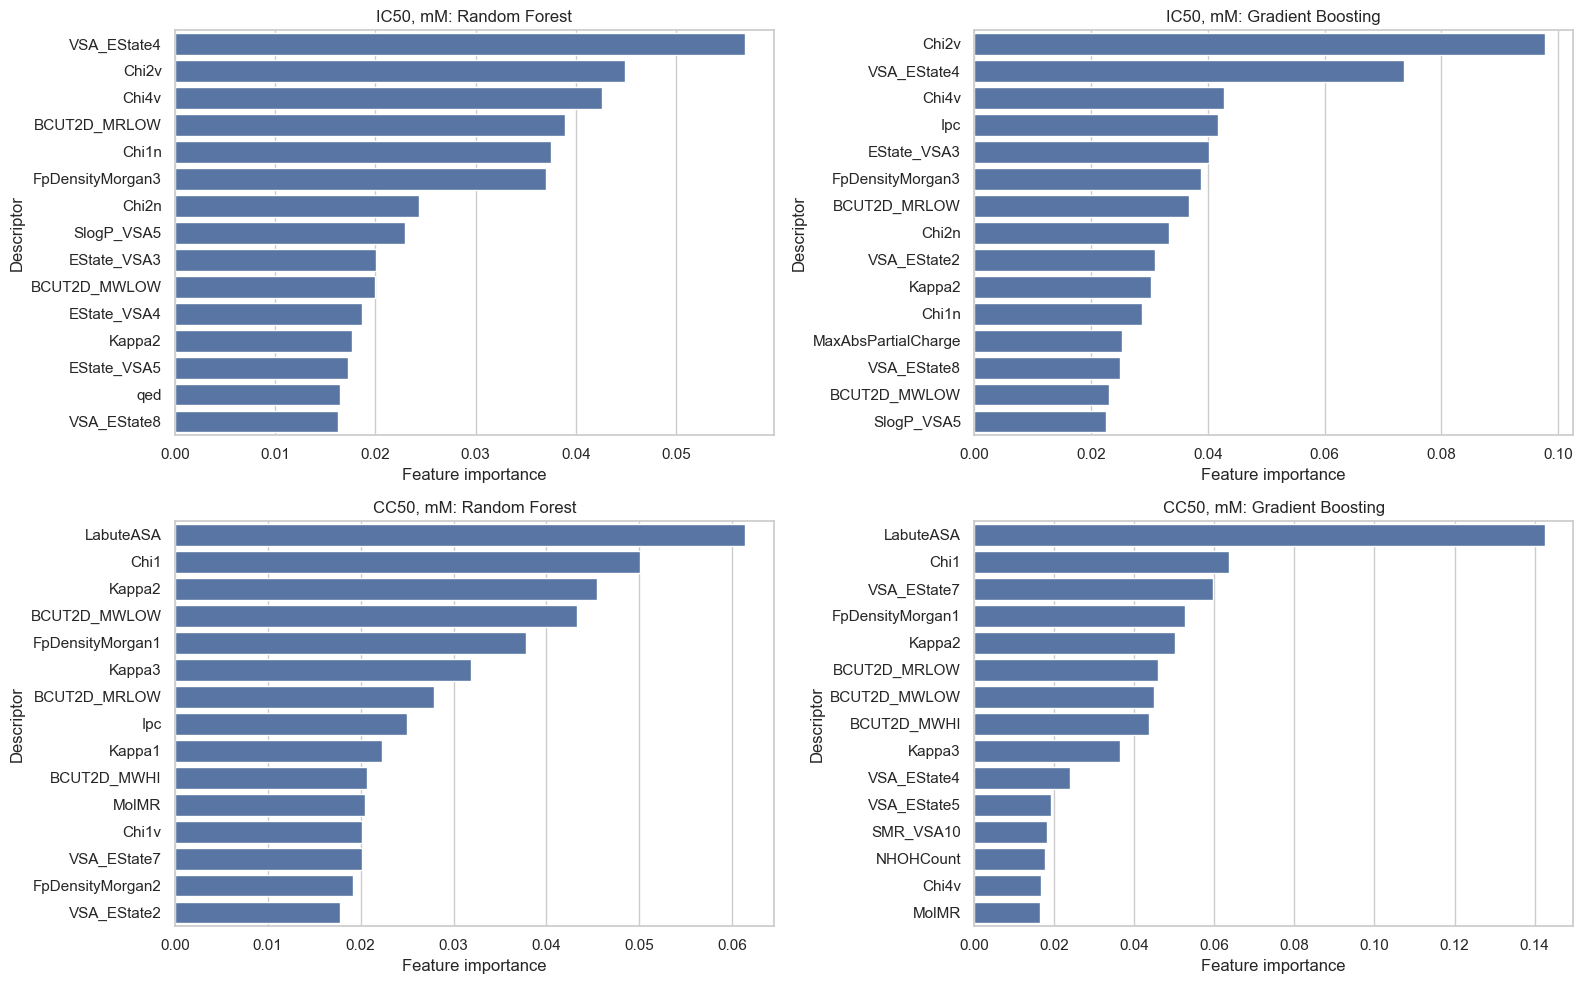

In [16]:
def plot_top_importances(pipeline: Pipeline, feature_names, title: str, top_n: int = 15):
    model = pipeline.named_steps['model']
    if not hasattr(model, 'feature_importances_'):
        return
    importances = pd.Series(model.feature_importances_, index=feature_names).sort_values(ascending=False).head(top_n)
    sns.barplot(x=importances.values, y=importances.index, color='#4C72B0')
    plt.title(title)
    plt.xlabel('Feature importance')
    plt.ylabel('Descriptor')

importance_targets = ['IC50, mM', 'CC50, mM']
fig, axes = plt.subplots(len(importance_targets), 2, figsize=(16, 10))
for row, target in enumerate(importance_targets):
    data = df.dropna(subset=[target]).copy()
    X = descriptor_matrix(data)
    y = data[target].astype(float)
    X_train, _, y_train, _ = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)
    models = [
        ('Random Forest', RandomForestRegressor(n_estimators=400, random_state=RANDOM_STATE, n_jobs=-1)),
        ('Gradient Boosting', GradientBoostingRegressor(random_state=RANDOM_STATE)),
    ]
    for col_idx, (model_name, model) in enumerate(models):
        pipeline = Pipeline([('imputer', SimpleImputer(strategy='median')), ('model', model)])
        pipeline.fit(X_train, y_train)
        plt.sca(axes[row, col_idx])
        plot_top_importances(pipeline, X.columns, f'{target}: {model_name}', top_n=15)
plt.tight_layout()
plt.show()



**Вывод.** Важные признаки следует интерпретировать как кандидаты для дальнейшего анализа, а не как доказательство причинности. Если среди top features неожиданно появляются target-like названия, это сигнал leakage; финальный pipeline предотвращает такую ситуацию через `get_target_like_columns()` и `validate_no_target_like_columns()`.


### 9.7 Confusion Matrix для лучших classification-моделей

Confusion matrix показывает, какие ошибки делает модель: false positives или false negatives. Это важно для drug discovery, где цена ошибки зависит от цели скрининга.


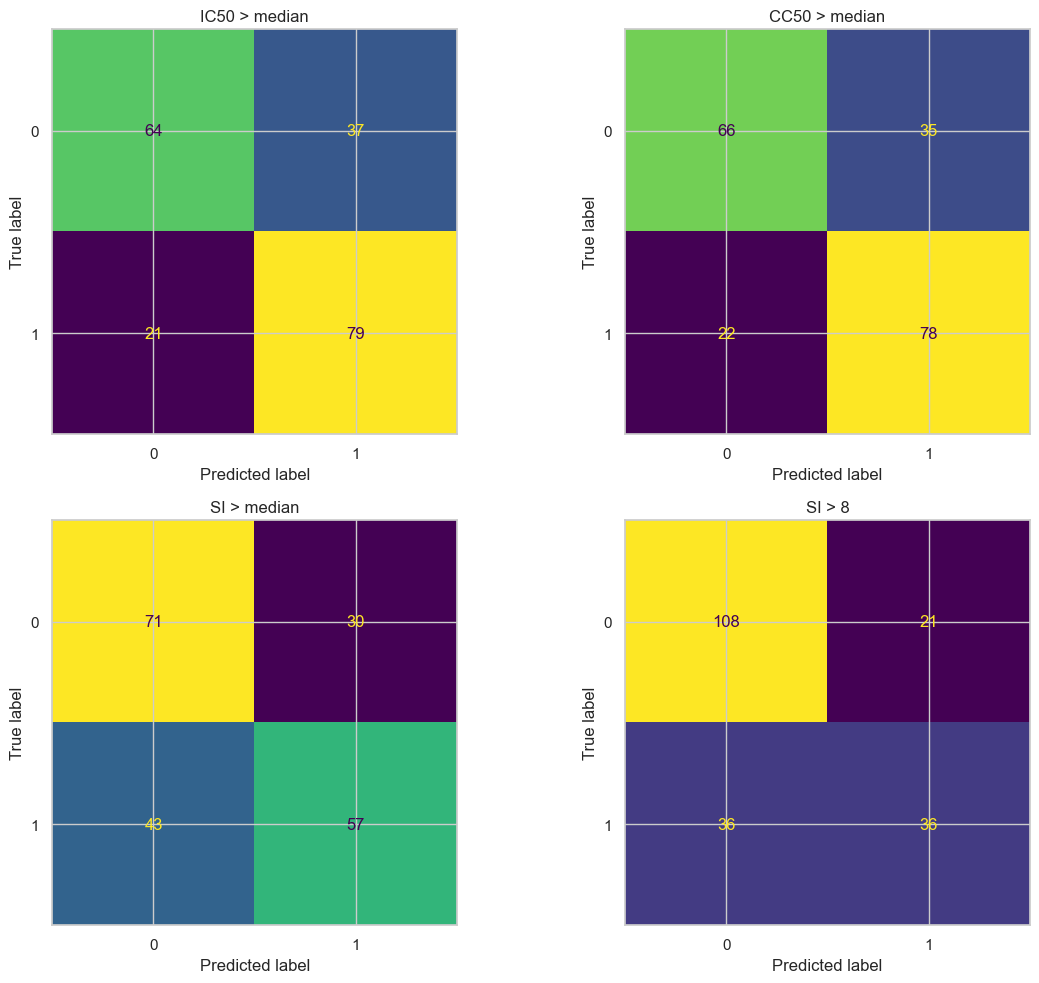

In [17]:
CLASSIFICATION_TASKS = {
    'IC50 > median': ('IC50, mM', float(df['IC50, mM'].median()), RandomForestClassifier(n_estimators=400, random_state=RANDOM_STATE, n_jobs=-1)),
    'CC50 > median': ('CC50, mM', float(df['CC50, mM'].median()), RandomForestClassifier(n_estimators=400, random_state=RANDOM_STATE, n_jobs=-1)),
    'SI > median': ('SI', float(df['SI'].median()), RandomForestClassifier(n_estimators=400, random_state=RANDOM_STATE, n_jobs=-1)),
    'SI > 8': ('SI', 8.0, RandomForestClassifier(n_estimators=400, random_state=RANDOM_STATE, n_jobs=-1)),
}

classification_diagnostics = {}
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.reshape(-1)
for ax, (task_name, (target_col, threshold, model)) in zip(axes, CLASSIFICATION_TASKS.items()):
    data = df.dropna(subset=[target_col]).copy()
    X = descriptor_matrix(data)
    y = (data[target_col] > threshold).astype(int)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
    )
    pipeline = Pipeline([('imputer', SimpleImputer(strategy='median')), ('model', model)])
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)[:, 1]
    classification_diagnostics[task_name] = {
        'pipeline': pipeline,
        'X_test': X_test,
        'y_test': y_test,
        'y_pred': y_pred,
        'y_proba': y_proba,
    }
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax, colorbar=False)
    ax.set_title(task_name)
plt.tight_layout()
plt.show()



**Вывод.** Для медианных задач классы примерно сбалансированы, поэтому confusion matrix легко интерпретировать. Для `SI > 8` положительный класс реже, поэтому особенно важно контролировать recall и PR-AUC: модель может иметь приемлемый ROC-AUC, но пропускать часть ценных high-SI соединений.


### 9.8 ROC curve и PR curve для лучших classification-моделей

ROC curve оценивает ранжирование при разных threshold. PR curve особенно полезна при дисбалансе классов, например для `SI > 8`.


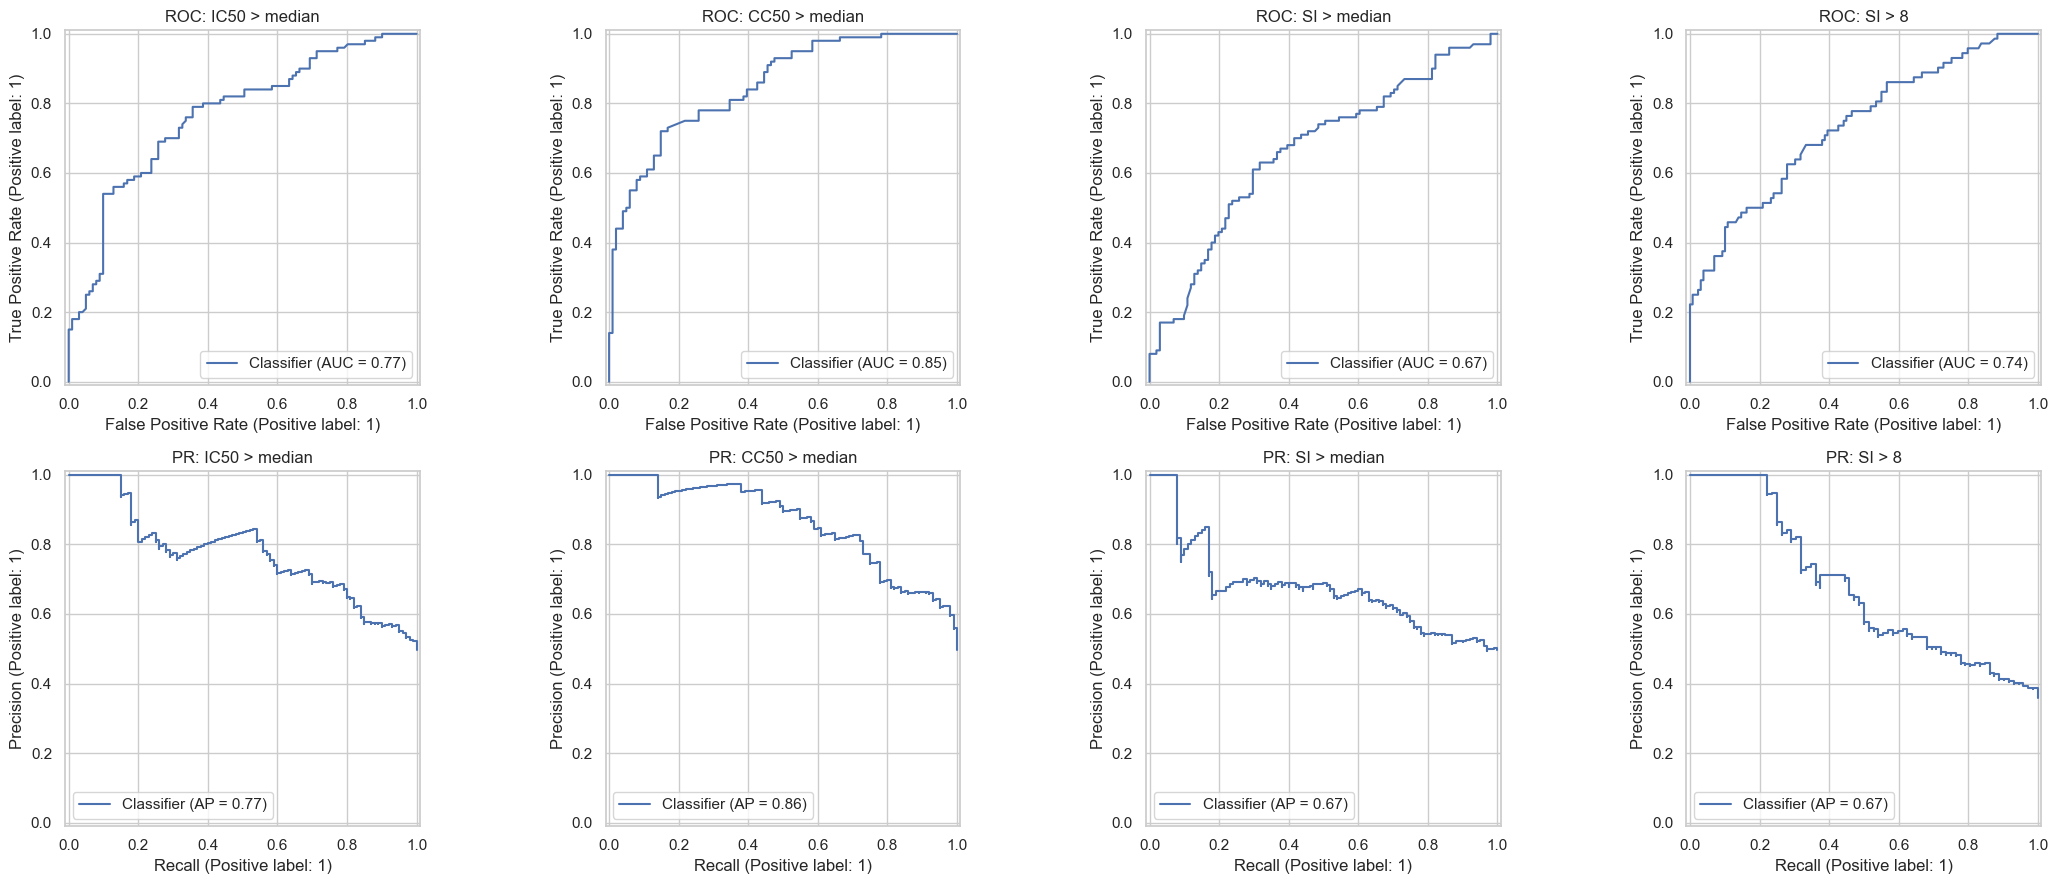

In [18]:
fig, axes = plt.subplots(2, 4, figsize=(22, 9))
for idx, (task_name, diagnostics) in enumerate(classification_diagnostics.items()):
    y_test = diagnostics['y_test']
    y_proba = diagnostics['y_proba']
    RocCurveDisplay.from_predictions(y_test, y_proba, ax=axes[0, idx])
    axes[0, idx].set_title(f'ROC: {task_name}')
    PrecisionRecallDisplay.from_predictions(y_test, y_proba, ax=axes[1, idx])
    axes[1, idx].set_title(f'PR: {task_name}')
plt.tight_layout()
plt.show()



**Вывод.** После исправления leakage ROC curves должны соответствовать реалистичным ROC-AUC из финальных результатов (`~0.65-0.83`), а не почти идеальным значениям. Если при повторном запуске ROC-AUC снова становится около `0.99-1.00`, это нужно трактовать как сигнал новой утечки, дубликатов или ошибки в разделении данных.


### Финальный вывод EDA

1. Данные в целом пригодны для моделирования: числовые дескрипторы, мало пропусков, понятные таргеты.  
2. Таргеты имеют выраженную асимметрию и выбросы, поэтому линейные модели полезны как baseline, но ансамбли деревьев ожидаемо сильнее.  
3. Критично соблюдать анти-утечку для задач с `SI`, иначе качество будет искусственно завышено.  
4. На следующем этапе корректно сравниваем модели с кросс-валидацией и подбором гиперпараметров.


## EDA: итоговая интерпретация и anti-leakage вывод

EDA показывает, что `IC50`, `CC50` и особенно `SI` имеют асимметричные распределения и выбросы. Выбросы не удаляются автоматически, потому что в drug discovery экстремальные значения могут соответствовать биологически важным соединениям.

Ключевой методологический вывод: `SI` является функцией `CC50` и `IC50`, поэтому endpoints и их производные нельзя использовать как признаки. Финальный pipeline применяет descriptor-only подход и удаляет target-like колонки до обучения. Это делает результаты classification и regression научно корректнее и предотвращает искусственно завышенный ROC-AUC.

